<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab8/L8_Colab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 8.1 Machine Learning 1 – Artificial Neural Network, Classification

##Learning goals

Students will be able to:

1. Create code to plot time and frequency domain data for normal and abnormal data
2. Implement an artificial neural network to classify different datasets


##Introduction

In this lab, we will create a machine learning (ML) model based on the accelerometer (ADXL345) signals to predict the running conditions of the axial flow fan (AFF) which we used in Lab 2. An autoencoder we practiced in Prelab8 will be employed to determine whether AFF is in a normal or abnormal condition. Lab8 is broken down into two main sections: **1) Data collection**, and **2) Training ML model**. In the data collection section, we will collect accelerometer data when the machine is in normal and abnormal conditions using Raspberry Pi. The abnormal condition will be set of increasing eccentric force by adding a mass on a blade of the AFF as Lab2. In the training ML model section, we will utilize the given scripts in Prelab8 to train an autoencoder. In addition, we will perform feature engineering by doing signal processing to see the effects of input feature on the performance of the ML models. And the, we will save the selected and trained model to local disk to use it in the next lab. The schematic of Lab9 is illustrated in Figure 1.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab8_fig1.png?raw=true" width="100%">

*Figure 1 Lab8: Schematic of anomaly detection model training for axial flow fan*

## Data Collection for Machine Learning

## Part 1: Data collection practice

First, make a wire connection between ADXL345 sensor and Raspberry Pi. If you are having trouble with the connection, please look at the instructions in Lab2 manual. After you make a connection, you are ready to collect data. Before attaching the sensor to the target placement, let’s try to get data and understand the output data format.

The sample Python script ([Lab8_data_collector.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab8/Lab8_data_collector.py?raw=true)) below to collect ADXL345 accelerometer data is on Github repo. In the script, what you need to pay attention to is ‘condition_identifier’ and ‘duration’ variables in the middle of the script.

---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_Python.png?raw=tru" width="20">Python - Python3 ([Lab8_data_collector.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab8/Lab8_data_collector.py?raw=true))**

```
import time
import board
import busio
import adafruit_adxl34x
from micropython import const
import csv
import datetime

i2c = busio.I2C(board.SCL, board.SDA) # i2c variable defines I2C interfaces and GPIO pins using busio and board modules

acc = adafruit_adxl34x.ADXL345(i2c) # acc object is instantiation using i2c of Adafruit ADXL34X library

acc.data_rate = const(0b1111) # change sampling rate as 3200 Hz

# ratedict=output rate dictionary
# See Table5 of Lab2 manual key=rate code (decimal), value=output data rate (Hz)
ratedict = {15:3200,14:1600,13:800,12:400,11:200,10:100,9:50,8:25,7:12.5,6:6.25,5:3.13,4:1.56,3:0.78,2:0.39,1:0.2,0:0.1}

print("Output data rate is {} Hz".format(ratedict[acc.data_rate])) # printing out data rate

def getData(sensor:object, N:int): # sensor: ADXL sensor object, N: The number of sample in each timestamp.
    t1 = time.time()
    data_x = [] # initialize data_x to contain x-axis acceleration
    data_y = [] # initialize data_y to contain y-axis acceleration
    data_z = [] # initialize data_z to contain z-axis acceleration
    for i in range(N):
        x_acc, y_acc, z_acc = sensor.acceleration
        data_x.append(str(x_acc))
        data_y.append(str(y_acc))
        data_z.append(str(z_acc))
    x_data = ' '.join(data_x)
    y_data = ' '.join(data_y)
    z_data = ' '.join(data_z)
    return x_data, y_data, z_data # each data returns space delimited string each element is measurement of acceleration

condition_identifier = "Test" # condition identifier
duration = 10 # data collection duration in second unit

filename = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")+"_"+condition_identifier+"_lab8_data.csv"
header = ["Condition", "Xacc array [m/s2]", "Yacc array [m/s2]", "Zacc array [m/s2]"]
start = time.time()

print("== Data collection for {} measurements started. ==".format(duration))

with open(filename, 'w') as f: # Make and open file object
    write = csv.writer(f) # write object for the created file
    write.writerow(header) # write the first row (header)
    for j in range(duration): # for measurement durations
        x, y, z = getData(acc, 1000) # get x-, y-, z-axis acceleration array of 1000 data points (1 second) for each
        print('======= {}th of {} collection ======='.format(j+1, duration)) # Print out the progress
        write.writerow([condition_identifier, x, y, z])
f.close()

print("== Data saving is done. == takes", time.time() - start)

```

---

Let’s try to collect data as a practice. Please set ‘condition_identifier’ as “test” and ‘duration’ as 10. If you run the script, your Raspberry Pi will collect accelerations for 10 seconds. According to Raspberry Pi specifications, the total time may be longer than the ‘duration’ you set. The output filename must be
“YYYYMMDD_HHmmSS_Test_lab8_data.csv”. The date-time in the first part of the filename is the date-time when the script starts to be run. The “Test” in this case is the ‘conditon_identifier’. If you open the saved CSV file, you will see the collected data as Table 1. The first column (Condition column) indicates
‘condition_identifier’. The second, third, and last columns indicate the measured accelerations for 1 second (1000 data points) for each axis, respectively. Because the sampling frequency is 1000Hz, each row means data for 1 second. Each array is space delimited float array. To practice data loading and transformation, perform Task 1.

<br></br>
*Table 1 Example of collected data*

<table width="100%">
<thead>
  <tr>
    <th>Condition</th>
    <th>Xacc array [m/s2]</th>
    <th>Yacc array [m/s2]</th>
    <th>Zacc array [m/s2]</th>
  </tr>
</thead>
<tbody>
  <tr>
    <td align="center" colspan="4">...</td>
  </tr>
  <tr>
    <td align="center">Test</td>
    <td align="center">x<sub>1</sub> x<sub>2</sub> … x<sub>999</sub> x<sub>1000</sub></td>
    <td align="center">y<sub>1</sub> y<sub>2</sub> … y<sub>999</sub> y<sub>1000</sub></td>
    <td align="center">z<sub>1</sub> z<sub>2</sub> … z<sub>999</sub> z<sub>1000</sub></td>
  </tr>
  <tr>
    <td align="center">Test</td>
    <td align="center">x<sub>1</sub> x<sub>2</sub> … x<sub>999</sub> x<sub>1000</sub></td>
    <td align="center">y<sub>1</sub> y<sub>2</sub> … y<sub>999</sub> y<sub>1000</sub></td>
    <td align="center">z<sub>1</sub> z<sub>2</sub> … z<sub>999</sub> z<sub>1000</sub></td>
  </tr>
  <tr>
    <td align="center">Test</td>
    <td align="center">x<sub>1</sub> x<sub>2</sub> … x<sub>999</sub> x<sub>1000</sub></td>
    <td align="center">y<sub>1</sub> y<sub>2</sub> … y<sub>999</sub> y<sub>1000</sub></td>
    <td align="center">z<sub>1</sub> z<sub>2</sub> … z<sub>999</sub> z<sub>1000</sub></td>
  </tr>
  <tr>
    <td align="center" colspan="4">...</td>
  </tr>
  <tr>
    <td align="center">Test</td>
    <td align="center">x<sub>1</sub> x<sub>2</sub> … x<sub>999</sub> x<sub>1000</sub></td>
    <td align="center">y<sub>1</sub> y<sub>2</sub> … y<sub>999</sub> y<sub>1000</sub></td>
    <td align="center">z<sub>1</sub> z<sub>2</sub> … z<sub>999</sub> z<sub>1000</sub></td>
  </tr>
  <tr>
    <td align="center">Test</td>
    <td align="center">x<sub>1</sub> x<sub>2</sub> … x<sub>999</sub> x<sub>1000</sub></td>
    <td align="center">y<sub>1</sub> y<sub>2</sub> … y<sub>999</sub> y<sub>1000</sub></td>
    <td align="center">z<sub>1</sub> z<sub>2</sub> … z<sub>999</sub> z<sub>1000</sub></td>
  </tr>
  <tr>
    <td align="center">Test</td>
    <td align="center">x<sub>1</sub> x<sub>2</sub> … x<sub>999</sub> x<sub>1000</sub></td>
    <td align="center">y<sub>1</sub> y<sub>2</sub> … y<sub>999</sub> y<sub>1000</sub></td>
    <td align="center">z<sub>1</sub> z<sub>2</sub> … z<sub>999</sub> z<sub>1000</sub></td>
  </tr>
  <tr>
    <td align="center" colspan="4">...</td>
  </tr>
</tbody>
</table>

### Task 1.1

After running ‘Lab8_data_collector.py’ with variables, ‘condition_identifier’=”Test” and ‘duration’=10, plot each axis data in both time-domain and frequency-domain as Figure 2. An example Python sciript for plotting data is given ([Lab8_plot_example.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab8/Lab8_plot_example.py?raw=true)). You can use the given Python script to plot data. However, it is strongly recommended to understand each line of the script.

* Capture the plot and attach it to the report below.

  * Load the CSV file you collected in Python script.

  * Add ‘condition_identifier’ and your name at the end of the title of each plot (e.g., ‘Time domain, Test, John Doe’).

  * Your plots must include each axis label and units.

  * Recall Lab2 and Prelab8. You have already done this work before.

  * Your data have 10 rows except the header row because you collected data for 10 seconds. Please select one of the data rows randomly.
  * You can use either Raspberry Pi or laptop to plot the data. If you want, perform plotting the given code in the code block below this Colab Notebook.



<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab8_fig2.png?raw=true" width="100%">

*Figure 2 Data plot: Time domain (left) and Frequency domain (right)*




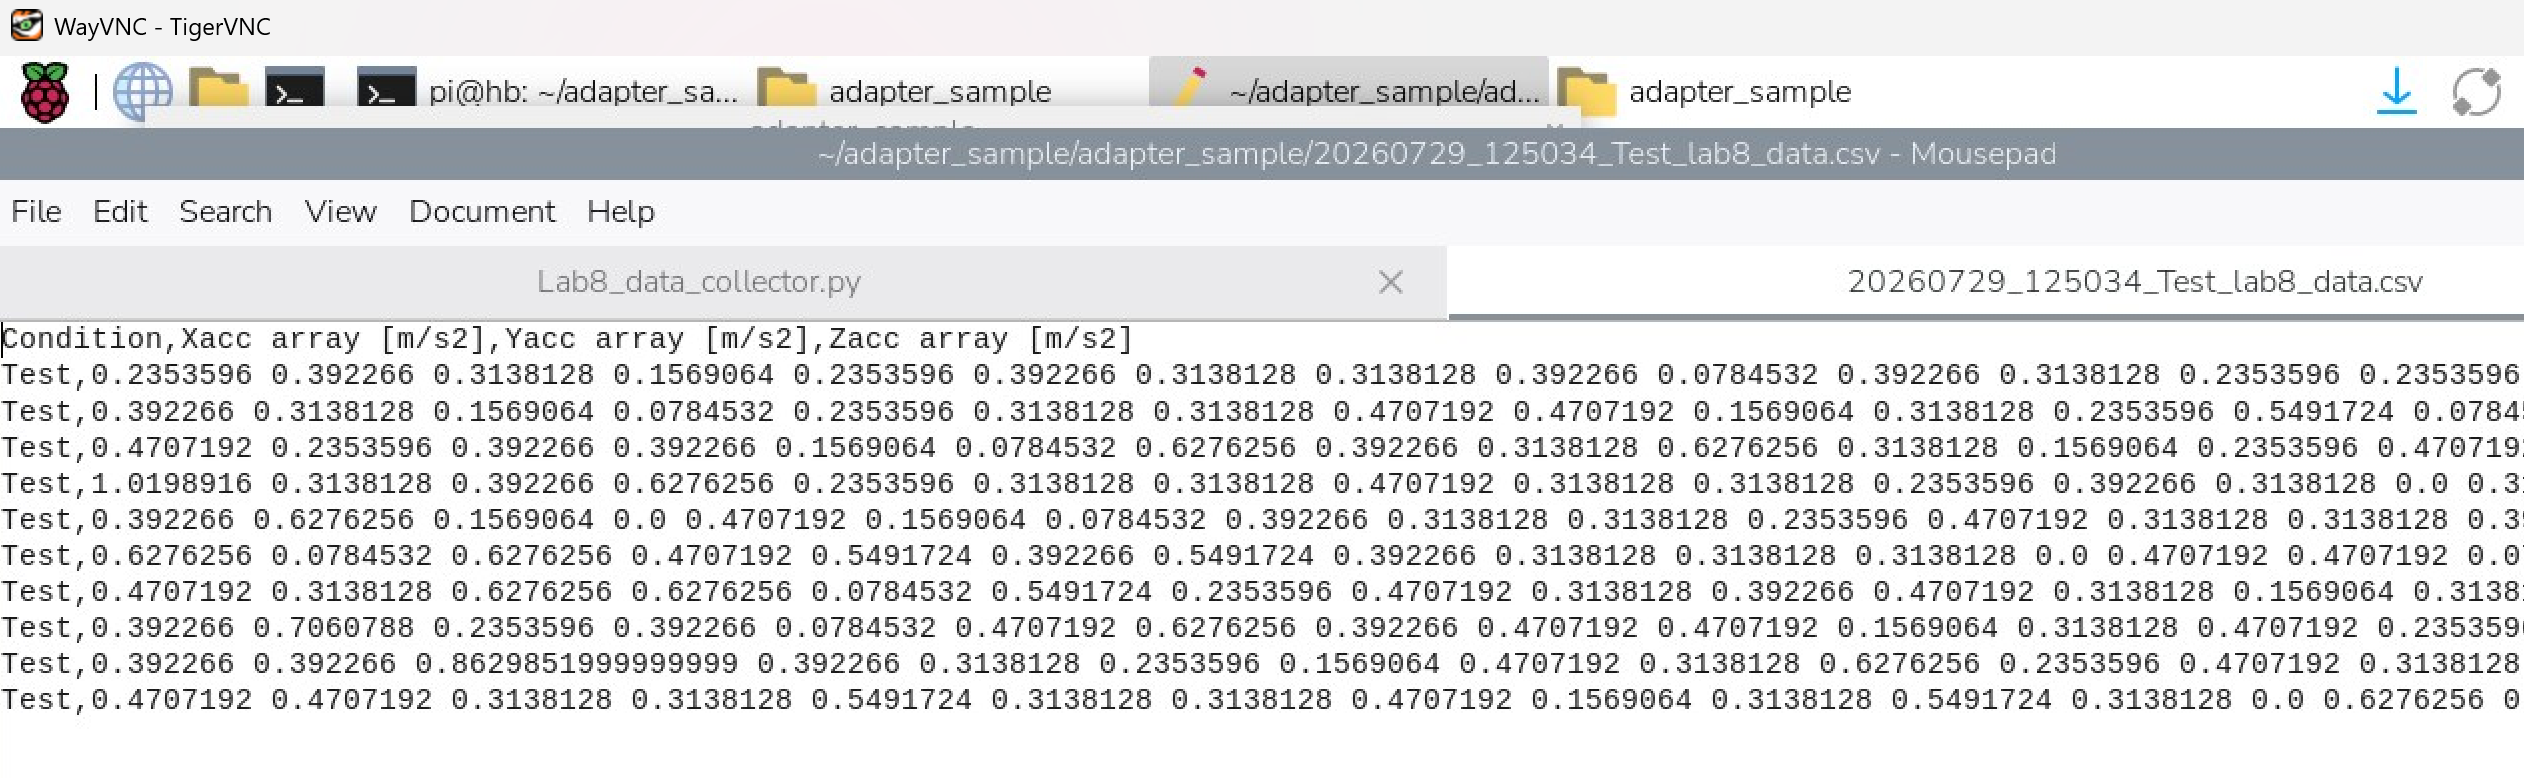

Saving file8_1.csv to file8_1.csv
Selected row index: 7


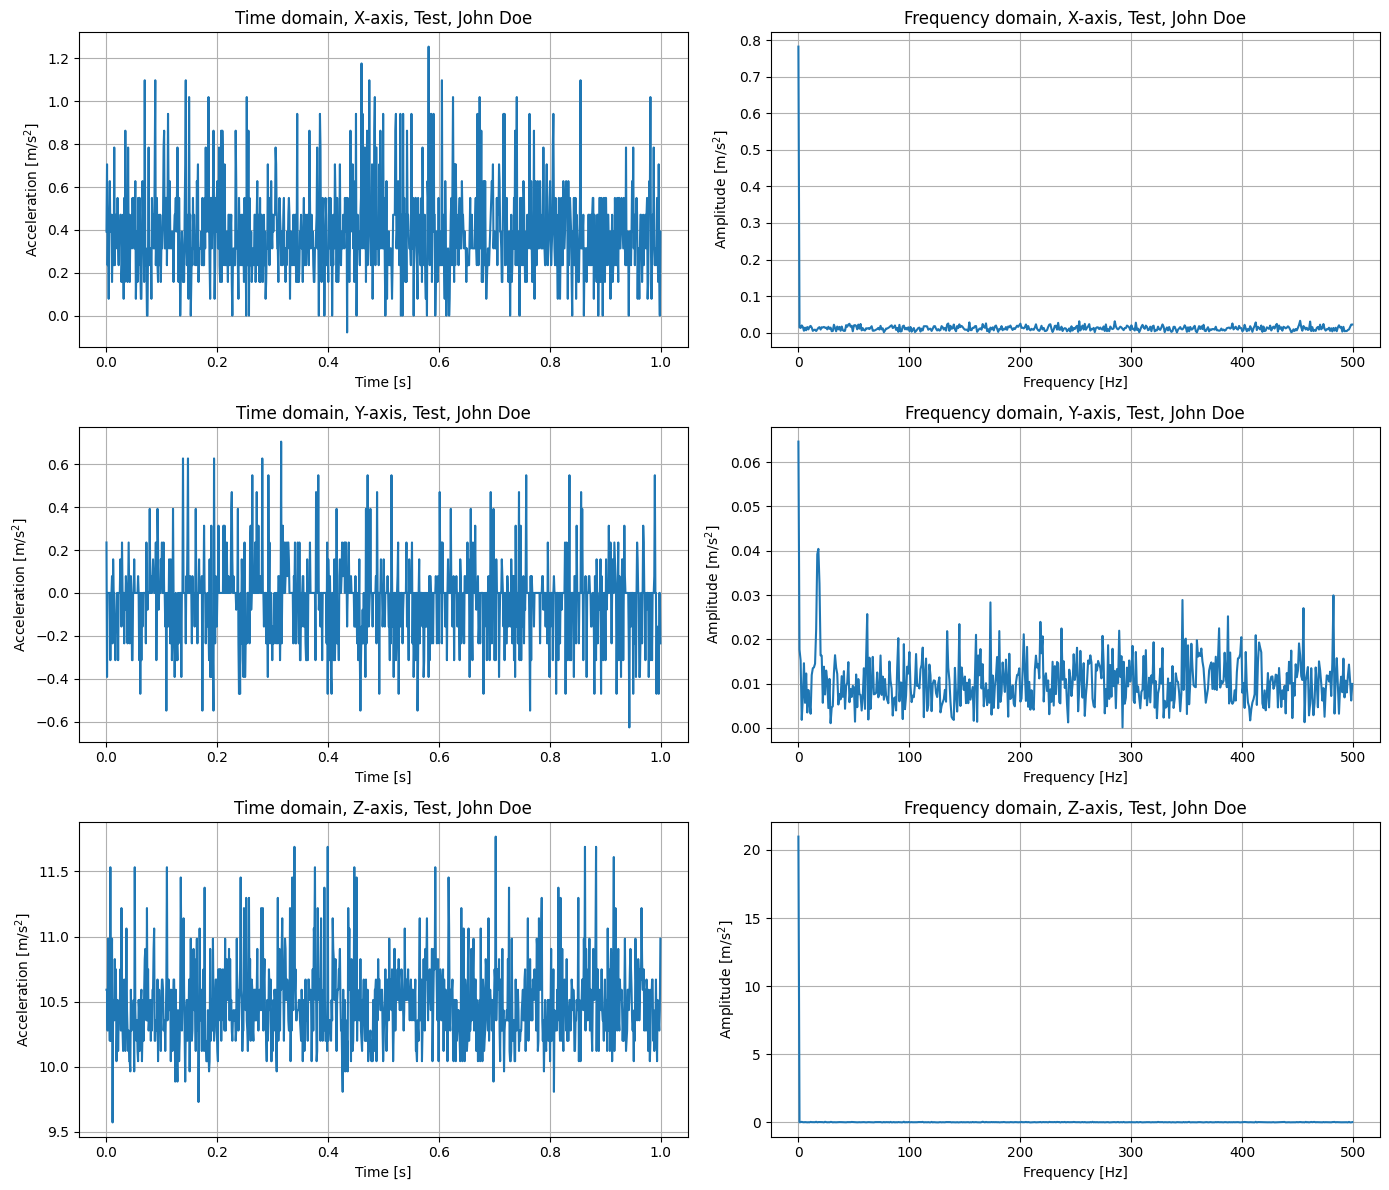

In [2]:
# --- Step 1: Upload file8_1.csv to Colab ---
from google.colab import files
uploaded = files.upload()   # file8_1.csv 선택해서 업로드

# --- Step 2: Plot Task 1.1 ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# ---- User inputs ----
condition_identifier = "Test"
your_name = "John Doe"          # 본인 이름으로 교체
csv_filename = "file8_1.csv"

# ---- Load the CSV file ----
df = pd.read_csv(csv_filename)

# ---- Randomly select one of the 10 rows ----
row_idx = random.randint(0, len(df) - 1)
row = df.iloc[row_idx]
print(f"Selected row index: {row_idx}")

# ---- Parse the space-delimited strings into float arrays ----
x_data = np.array(row['Xacc array [m/s2]'].split(' '), dtype=float)
y_data = np.array(row['Yacc array [m/s2]'].split(' '), dtype=float)
z_data = np.array(row['Zacc array [m/s2]'].split(' '), dtype=float)

# ---- Sampling parameters ----
N = len(x_data)
Ts = 1 / 1000
Fs = 1 / Ts
time_axis = np.arange(N) * Ts

axes_data = {'X': x_data, 'Y': y_data, 'Z': z_data}

# ---- Plot time-domain and frequency-domain for each axis ----
fig, axs = plt.subplots(3, 2, figsize=(14, 12))

for i, (axis_name, signal) in enumerate(axes_data.items()):
    # --- Time domain ---
    axs[i, 0].plot(time_axis, signal)
    axs[i, 0].set_xlabel('Time [s]')
    axs[i, 0].set_ylabel('Acceleration [m/s$^2$]')
    axs[i, 0].set_title(f'Time domain, {axis_name}-axis, {condition_identifier}, {your_name}')
    axs[i, 0].grid()

    # --- Frequency domain (FFT) ---
    fft_vals = np.fft.fft(signal)
    fft_freq = np.fft.fftfreq(N, d=Ts)
    half = N // 2
    freq_pos = fft_freq[:half]
    magnitude = (2.0 / N) * np.abs(fft_vals[:half])

    axs[i, 1].plot(freq_pos, magnitude)
    axs[i, 1].set_xlabel('Frequency [Hz]')
    axs[i, 1].set_ylabel('Amplitude [m/s$^2$]')
    axs[i, 1].set_title(f'Frequency domain, {axis_name}-axis, {condition_identifier}, {your_name}')
    axs[i, 1].grid()

plt.tight_layout()
plt.show()

## Part 2: Data collection in normal condition

Before we deploy the sensor to the AFF, let’s check the hardware and the speed controller. The hardware configuration and the speed controller are shown in Figure 3. For safety reasons, the base part is fixed on the table using tapes. Do not remove the tapes because it maybe move when you run the AFF due to aerodynamic forces. To turn on the fan, rotate the knob of the speed controller clockwise. The relationship between knob pointer placements and the actual rotational speed of AFF is shown in Table 2. When you rotate the pointer of the knob to L (Speed 1 in Figure 3 (right)), for example, the AFF rotates around 1800 rpm. By adjusting the control knob, you can increase and decrease the rotating speed of the fan. Different from the vacuum pump case of Prelab8, it is obvious that changing rotational speed makes an ML model development hard. On the other hand, it may be more interesting. For instance, if you attach the unbalanced mass to a blade of the fan at the lowest rotational speed, does the amplitude of vibration be bigger than the maximum rotational speed without any attached mass? We don’t know the answer exactly but probably no. Turn the fan on and adjust the knob to see if the rotation speed changes well.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab8_fig3.png?raw=true" width="100%">

*Figure 3 Configuration of axial flow fan (left) and speed controller (right)*
<br></br>
*Table 2 Controller indicator vs. rotational speed of AFF*

<table width="60%">
<thead>
  <tr>
    <th align="center">Speed indiator</th>
    <th align="center">Rotational Speed</th>
  </tr>
</thead>
<tbody>
  <tr>
    <td align="center">1 (L, Low)</td>
    <td align="center">1800 rpm</td>
  </tr>
  <tr>
    <td align="center">2</td>
    <td align="center">2150 rpm</td>
  </tr>
  <tr>
    <td align="center">3 (M, Middle)</td>
    <td align="center">2500 rpm</td>
  </tr>
  <tr>
    <td align="center">4</td>
    <td align="center">2750 rpm</td>
  </tr>
  <tr>
    <td align="center">5 (H, High)</td>
    <td align="center">3000 rpm</td>
  </tr>
</tbody>
</table>

Deploy the accelerometer (ADXL345) on the top of the fan as Figure 4. **You have to remember the sensor placement and the axis configuration for the next lab again.** If you are not sure how to set up the accelerometer to the AFF, please look at [Lab2.2 manual](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab2/L2_Colab2.ipynb). To collect acceleration data when the machine is in normal conditions for 5 minutes, perform Task 1.2. While you collect the data, try to change the rotational speed. For example, while collecting, set Speed 1 (1800 rpm) for the first 1 minute, and then Speed 2 (2150 rpm) between 1 and 2 minutes and so forth. The example of the experimental table is shown in Table 3. You see the progress of your data collector in the Shell of Thonny or Terminal window of Raspberry Pi as Figure 5. For this, please perform data collection at once with other members sharing the table and the AFF.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab8_fig4.png?raw=true" width="50%">

*Figure 4 Sensor placement on top of the AFF*
<br></br>
*Table 3 Experimental table for data collection of AFF*

<table width=60%>
<thead>
  <tr>
    <th>Measurement</th>
    <th>Time (Approximately)</th>
    <th>Speed</th>
  </tr>
</thead>
<tbody>
  <tr>
    <td align="center">1 - 60</td>
    <td align="center">0 - 60 seconds</td>
    <td align="center">1 (L, 1800 rpm)</td>
  </tr>
  <tr>
    <td align="center">61 - 120</td>
    <td align="center">61 - 120 seconds</td>
    <td align="center">2 (2150 rpm)</td>
  </tr>
  <tr>
    <td align="center">121 - 180</td>
    <td align="center">121 - 180 seconds</td>
    <td align="center">3 (M, 2500 rpm)</td>
  </tr>
  <tr>
    <td align="center">181 - 240</td>
    <td align="center">181 - 240 seconds</td>
    <td align="center">4 (2750 rpm)</td>
  </tr>
  <tr>
    <td align="center">241 - 300</td>
    <td align="center">241 - 300 seconds</td>
    <td align="center">5 (3000 rpm)</td>
  </tr>
</tbody>
</table>

<br></br>

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab8_fig5.png?raw=true" width="80%">

*Figure 5 Data collection progress check: Thonny (left) and Terminal (right)*

### Task 1.2

Run ‘Lab8_data_collector.py’ while you run the AFF with variables, ‘condition_identifier’=”Normal” and ‘duration’=300, plot each axis data in both time-domain and frequency-domain as Figure 2.

* Capture the plots according to the rotational speed and attach these to the report below.

  *	Load the CSV file in Python script.

  *	Add ‘condition_identifier’, rotational speed, and your name at the end of the title of each plot (e.g., ‘Time domain, Normal, 1800 rpm, John Doe’).

  *	Your plots must include each axis label and units.

  *	**Plot two different rotational speeds and compare them** For example, one is 1800 rpm and another is 2500 rpm.

* Your data have 300 rows except the header row because you collected data for 300 seconds. Note that the actual collection time is probably loger than 300 seconds because of data saving time. Please select one of the data rows randomly within one-speed range. For example, if you plot Speed 2, you need to select a data row between 61 and 120.






In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from google.colab import files

# ==========================================
# 1. 사용자 설정 (본인 환경에 맞게 수정)
# ==========================================
USER_NAME = "Hyobin Park"            # 본인 이름
CONDITION = "Normal"              # 과제 조건
SAMPLING_RATE = 10000             # 샘플링 주파수 (Hz)

# ==========================================
# 2. Normal CSV 파일 업로드
# ==========================================
print("Normal 상태의 CSV 파일 1개를 업로드하세요:")
uploaded = files.upload()
file_path = list(uploaded.keys())[0]

# 데이터 로드
df = pd.read_csv(file_path)

# ==========================================
# 3. 1800 rpm 구간 (1~60행 -> 인덱스 0~59) 무작위 선택
# ==========================================
row_idx = random.randint(0, min(59, len(df) - 1))
print(f"1800 rpm 선택된 행 번호: {row_idx + 1}행")

row_data = df.iloc[row_idx]
samples_per_axis = len(row_data) // 3

# 3축 신호 분리
sig_x = row_data.iloc[0 : samples_per_axis].values.astype(float)
sig_y = row_data.iloc[samples_per_axis : 2 * samples_per_axis].values.astype(float)
sig_z = row_data.iloc[2 * samples_per_axis : 3 * samples_per_axis].values.astype(float)

# 시간 축 생성 (단위: s)
time_axis = np.arange(len(sig_x)) / SAMPLING_RATE

# FFT (주파수 영역) 계산 함수
def compute_fft(sig, fs):
    N = len(sig)
    fft_val = np.fft.rfft(sig)
    fft_mag = np.abs(fft_val) * (2.0 / N)
    freq = np.fft.rfftfreq(N, 1.0 / fs)
    return freq, fft_mag

freq_x, fft_x = compute_fft(sig_x, SAMPLING_RATE)
freq_y, fft_y = compute_fft(sig_y, SAMPLING_RATE)
freq_z, fft_z = compute_fft(sig_z, SAMPLING_RATE)

# ==========================================
# 4. 플로팅 (Figure 2 스타일)
# ==========================================
fig, axes = plt.subplots(3, 2, figsize=(15, 11))
fig.suptitle(f"{CONDITION}, 1800 rpm, {USER_NAME}", fontsize=16, fontweight='bold')

plot_configs = [
    ("X-axis", sig_x, freq_x, fft_x),
    ("Y-axis", sig_y, freq_y, fft_y),
    ("Z-axis", sig_z, freq_z, fft_z)
]

for i, (axis_name, sig, freq, fft_mag) in enumerate(plot_configs):
    # Time Domain Plot
    axes[i, 0].plot(time_axis, sig, color='navy', alpha=0.8)
    axes[i, 0].set_title(f"Time domain ({axis_name}), {CONDITION}, 1800 rpm, {USER_NAME}")
    axes[i, 0].set_xlabel("Time [s]")
    axes[i, 0].set_ylabel("Acceleration [m/s²]")  # 필요 시 단위 수정 (예: g, V)
    axes[i, 0].grid(True, linestyle='--', alpha=0.6)

    # Frequency Domain Plot
    axes[i, 1].plot(freq, fft_mag, color='crimson', alpha=0.8)
    axes[i, 1].set_title(f"Frequency domain ({axis_name}), {CONDITION}, 1800 rpm, {USER_NAME}")
    axes[i, 1].set_xlabel("Frequency [Hz]")
    axes[i, 1].set_ylabel("Magnitude")
    axes[i, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Normal 상태의 CSV 파일 1개를 업로드하세요:


Saving 1800n.csv to 1800n (3).csv
1800 rpm 선택된 행 번호: 54행


ValueError: could not convert string to float: '-1.4055128545229523 0.18462739792134947 -0.3409444573117634 0.3572512162748357 0.44869172149046316 -0.04087544577020174 -0.061248056046698925 0.16152746965873171 0.04955114557481683 -0.7280365902965605 0.21959527109328453 -0.42306769418816004 -0.3373412822017561 0.7793223867015476 0.0028271401877804745 -0.3475106648605391 -0.4617857411338193 -0.6256901805061877 0.3455009366175386 0.2503839987022358 0.058666920797849825 -0.27924682174896276 -0.07732877238254739 -0.4719290626138475 -1.1610774658679044 -0.001194695519603074 0.42138683537769417 0.41669775970937917 -0.5135959365676047 -0.09878858403726543 0.6091732833744825 0.5923543124152388 -0.3972942019794022 -0.20777208713079878 0.24026210913548607 0.3786461824924962 0.7977905639632209 -0.39470013527863235 0.2503252994894851 1.0207392522315224 -0.6204404263991296 0.4546406137039981 -0.2762926517008314 0.8328895511564137 -0.14611777520855257 -0.4440178999776868 1.0572672193018942 -0.3066967

## Part 3: Data collection in abnormal condition

Next step is to collect abnormal condition data by adding mass on the blade for the ML model. There will be an adhesive putty on top of the AFF. Using the putty, make the fan unbalanced as Figure 6. If you are not sure how to set up the abnormal condition by adding mass, please review [Lab2.2 manual](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab2/L2_Colab2.ipynb). Please safely disassemble and assemble the AFF. If you are unsure about your setup, please ask TA. After setup for the abnormal condition of the AFF, perform TASK 3.

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab8_fig6.png?raw=true" width="50%">

*Figure 6 Unbalanced fan blade for abnormal condition of AFF*

### Task 1.3 (Repeat Task 1.2 in *abnormal* condition)

Run ‘Lab8_data_collector.py’ while you run the AFF with variables, ‘condition_identifier’=”Abnormal” and ‘duration’=300, plot each axis data in both time-domain and frequency-domain as Figure 2.

* Capture the plots according to the rotational speed and attach these to the report below.

  *	Load the CSV file in Python script.

  *	Add ‘condition_identifier’, rotational speed, and your name at the end of the title of each plot (e.g., ‘Time domain, Abnormal, 1800 rpm, John Doe’).

  *	Your plots must include each axis label and units.

  *	**Plot two different rotational speeds and compare them** For example, one is 1800 rpm and another is 2500 rpm.

* Your data have 300 rows except the header row because you collected data for 300 seconds. Note that the actual collection time is probably loger than 300 seconds because of data saving time. Please select one of the data rows randomly within one-speed range. For example, if you plot Speed 2, you need to select a data row between 61 and 120.

---

Place your screenshot for Task 1.3 (speed condition 1) here in case you use Raspberry Pi or Python on your laptop.

---


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from google.colab import files

# ==========================================
# 1. 사용자 설정
# ==========================================
USER_NAME = "HyobinPark"           # 본인 이름
CONDITION = "Abnormal"            # Task 1.3 조건: Abnormal
SAMPLING_RATE = 10000             # 샘플링 주파수 (Hz)

# ==========================================
# 2. Abnormal CSV 파일 업로드
# ==========================================
print("Abnormal 상태의 CSV 파일을 업로드하세요:")
uploaded = files.upload()
file_path = list(uploaded.keys())[0]

# 데이터 로드
df = pd.read_csv(file_path)

# 숫자형 데이터 컬럼만 선택 (시간, 문자열 컬럼 자동 제외)
numeric_df = df.select_dtypes(include=[np.number])

# ==========================================
# 3. 데이터 구조 자동 감지 및 1800 rpm 신호 추출
# ==========================================
# [구조 A] 데이터가 세로(Column) 방향(X, Y, Z축)으로 길게 들어있는 경우
if numeric_df.shape[1] >= 3 and numeric_df.shape[0] > 300:
    total_rows = len(numeric_df)
    chunk_size = total_rows // 300 if total_rows >= 300 else total_rows

    # 1800 rpm 구간: 1~60번째 블록/초 중 랜덤 선택 (인덱스 0~59)
    sec_idx = random.randint(0, 59)
    start_row = sec_idx * chunk_size
    end_row = start_row + chunk_size

    sig_x = numeric_df.iloc[start_row:end_row, 0].values.astype(float)
    sig_y = numeric_df.iloc[start_row:end_row, 1].values.astype(float)
    sig_z = numeric_df.iloc[start_row:end_row, 2].values.astype(float)
    print(f"1800 rpm 선택된 구간: {sec_idx + 1}번째 초 데이터 (샘플 수: {len(sig_x)}개)")

# [구조 B] 데이터가 가로(Row) 방향(1행 = 1회 측정 신호)으로 나열된 경우
else:
    max_idx = min(59, len(numeric_df) - 1)
    row_idx = random.randint(0, max_idx)
    print(f"1800 rpm 선택된 행 번호: {row_idx + 1}행")

    row_data = numeric_df.iloc[row_idx].values.astype(float)
    samples_per_axis = int(len(row_data) // 3)

    sig_x = row_data[0 : samples_per_axis]
    sig_y = row_data[samples_per_axis : 2 * samples_per_axis]
    sig_z = row_data[2 * samples_per_axis : 3 * samples_per_axis]

# ==========================================
# 4. FFT (주파수 영역) 및 시간 축 계산
# ==========================================
time_axis = np.arange(len(sig_x)) / float(SAMPLING_RATE)

def compute_fft(sig, fs):
    N = len(sig)
    if N == 0:
        raise ValueError("신호 데이터 길이가 0입니다. CSV 파일 구성을 확인해 주세요.")
    fft_val = np.fft.rfft(sig)
    fft_mag = np.abs(fft_val) * (2.0 / N)
    freq = np.fft.rfftfreq(N, 1.0 / fs)
    return freq, fft_mag

freq_x, fft_x = compute_fft(sig_x, SAMPLING_RATE)
freq_y, fft_y = compute_fft(sig_y, SAMPLING_RATE)
freq_z, fft_z = compute_fft(sig_z, SAMPLING_RATE)

# ==========================================
# 5. 플로팅
# ==========================================
fig, axes = plt.subplots(3, 2, figsize=(15, 11))
fig.suptitle(f"{CONDITION}, 1800 rpm, {USER_NAME}", fontsize=16, fontweight='bold')

plot_configs = [
    ("X-axis", sig_x, freq_x, fft_x),
    ("Y-axis", sig_y, freq_y, fft_y),
    ("Z-axis", sig_z, freq_z, fft_z)
]

for i, (axis_name, sig, freq, fft_mag) in enumerate(plot_configs):
    # Time Domain Plot
    axes[i, 0].plot(time_axis, sig, color='navy', alpha=0.8)
    axes[i, 0].set_title(f"Time domain ({axis_name}), {CONDITION}, 1800 rpm, {USER_NAME}")
    axes[i, 0].set_xlabel("Time [s]")
    axes[i, 0].set_ylabel("Acceleration [m/s²]")
    axes[i, 0].grid(True, linestyle='--', alpha=0.6)

    # Frequency Domain Plot
    axes[i, 1].plot(freq, fft_mag, color='crimson', alpha=0.8)
    axes[i, 1].set_title(f"Frequency domain ({axis_name}), {CONDITION}, 1800 rpm, {USER_NAME}")
    axes[i, 1].set_xlabel("Frequency [Hz]")
    axes[i, 1].set_ylabel("Magnitude")
    axes[i, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

[1800 rpm] Abnormal CSV 파일을 업로드하세요:


Saving 1800abn.csv to 1800abn (6).csv
전체 샘플 수: 0개
1초당 샘플 수: 0개
선택된 구간: 54번째 초 데이터 (추출된 샘플: 0개)


ValueError: 추출된 데이터 길이가 0입니다. CSV 파일을 확인해주세요.

---

Place your screenshot for Task 1.3 (speed condition 2) here in case you use Raspberry Pi or Python on your laptop.

---

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from google.colab import files

# ==========================================
# 1. 사용자 설정
# ==========================================
USER_NAME = "Hyobin Park"         # 본인 이름
CONDITION = "Abnormal"            # Task 1.3 조건
SAMPLING_RATE = 10000             # 샘플링 주파수 (Hz)

# ==========================================
# 2. Abnormal CSV 파일 업로드
# ==========================================
print("Abnormal 상태의 CSV 파일을 업로드하세요:")
uploaded = files.upload()
file_path = list(uploaded.keys())[0]

# 데이터 로드
df = pd.read_csv(file_path)

# 숫자형 데이터 컬럼만 선택
numeric_df = df.select_dtypes(include=[np.number])

# ==========================================
# 3. 데이터 구조 자동 감지 및 신호 추출
# ==========================================
# [구조 A] 데이터가 열(Column) 방향(X, Y, Z축)으로 들어있는 경우
if numeric_df.shape[1] >= 3 and numeric_df.shape[0] > 300:
    print("-> Detected Format: Column-based data (Vertical structure)")
    # 2500 rpm 구간: 전체 데이터 중 121~180번째 블록/구간에서 데이터 추출
    # 샘플 개수에 따라 1초 단위 샘플 수 산출
    total_rows = len(numeric_df)
    chunk_size = total_rows // 300 if total_rows >= 300 else total_rows

    # 121~180 구간 무작위 선택
    sec_idx = random.randint(120, 179)
    start_row = sec_idx * chunk_size
    end_row = start_row + chunk_size

    sig_x = numeric_df.iloc[start_row:end_row, 0].values.astype(float)
    sig_y = numeric_df.iloc[start_row:end_row, 1].values.astype(float)
    sig_z = numeric_df.iloc[start_row:end_row, 2].values.astype(float)

# [구조 B] 데이터가 행(Row) 방향(1행에 한 번의 측정 데이터가 나열)으로 들어있는 경우
else:
    print("-> Detected Format: Row-based data (Horizontal structure)")
    max_idx = min(179, len(numeric_df) - 1)
    min_idx = min(120, max_idx)
    row_idx = random.randint(min_idx, max_idx)
    print(f"2500 rpm 선택된 행 번호: {row_idx + 1}행")

    row_data = numeric_df.iloc[row_idx].values.astype(float)
    samples_per_axis = len(row_data) // 3

    sig_x = row_data[0 : samples_per_axis]
    sig_y = row_data[samples_per_axis : 2 * samples_per_axis]
    sig_z = row_data[2 * samples_per_axis : 3 * samples_per_axis]

# 데이터 개수 검증
print(f"추출된 신호 길이 (X축): {len(sig_x)}개 샘플")

# ==========================================
# 4. FFT (주파수 영역) 및 시간 축 계산
# ==========================================
time_axis = np.arange(len(sig_x)) / float(SAMPLING_RATE)

def compute_fft(sig, fs):
    N = len(sig)
    if N == 0:
        raise ValueError("신호 데이터 길이가 0입니다. CSV 데이터 구조를 확인해주세요.")
    fft_val = np.fft.rfft(sig)
    fft_mag = np.abs(fft_val) * (2.0 / N)
    freq = np.fft.rfftfreq(N, 1.0 / fs)
    return freq, fft_mag

freq_x, fft_x = compute_fft(sig_x, SAMPLING_RATE)
freq_y, fft_y = compute_fft(sig_y, SAMPLING_RATE)
freq_z, fft_z = compute_fft(sig_z, SAMPLING_RATE)

# ==========================================
# 5. 플로팅
# ==========================================
fig, axes = plt.subplots(3, 2, figsize=(15, 11))
fig.suptitle(f"{CONDITION}, 2500 rpm, {USER_NAME}", fontsize=16, fontweight='bold')

plot_configs = [
    ("X-axis", sig_x, freq_x, fft_x),
    ("Y-axis", sig_y, freq_y, fft_y),
    ("Z-axis", sig_z, freq_z, fft_z)
]

for i, (axis_name, sig, freq, fft_mag) in enumerate(plot_configs):
    # Time Domain Plot
    axes[i, 0].plot(time_axis, sig, color='navy', alpha=0.8)
    axes[i, 0].set_title(f"Time domain ({axis_name}), {CONDITION}, 2500 rpm, {USER_NAME}")
    axes[i, 0].set_xlabel("Time [s]")
    axes[i, 0].set_ylabel("Acceleration [m/s²]")
    axes[i, 0].grid(True, linestyle='--', alpha=0.6)

    # Frequency Domain Plot
    axes[i, 1].plot(freq, fft_mag, color='crimson', alpha=0.8)
    axes[i, 1].set_title(f"Frequency domain ({axis_name}), {CONDITION}, 2500 rpm, {USER_NAME}")
    axes[i, 1].set_xlabel("Frequency [Hz]")
    axes[i, 1].set_ylabel("Magnitude")
    axes[i, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Abnormal 상태의 CSV 파일을 업로드하세요:


Saving 2500abn.csv to 2500abn (3).csv
-> Detected Format: Row-based data (Horizontal structure)
2500 rpm 선택된 행 번호: 30행
추출된 신호 길이 (X축): 0개 샘플


ValueError: 신호 데이터 길이가 0입니다. CSV 데이터 구조를 확인해주세요.

### Task 1.4

Upload the CSV files for Task 1.1-1.3 on Brightspace alongside your lab submission.

  *	You do not need to upload the Python script.

  *	Leave the CSV filenames as generated.


<br></br>

Please continue to [Lab 8.2 here](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab8/L8_Colab2.ipynb).
